# Phase 1: Standalone Clarification Subgraph (SRS Subagent)
This notebook implements **Phase 1** of `SRS_Subgraph_Implementation_Plan.md`.
It builds a stateful, multi-turn Human-in-the-Loop (HITL) requirements-gathering engine that extracts and formalizes software requirements into an IEEE 830-aligned model.

### Architectural Invariants:
1. **Zero-LLM Interrupt**: Question generation is decoupled from the `interrupt()` node to prevent token burn upon resume.
2. **Delta Requirements Merging**: Updates merge only the latest human answer into the existing model, keeping token costs flat.
3. **Forced Gap Enumeration**: Completeness checks require explicit identification of ambiguities before declaring saturation.


In [ ]:
import os
import sys
import json
import time
import asyncio
import operator
import threading
from pathlib import Path
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Literal

from dotenv import load_dotenv, dotenv_values
from pydantic import BaseModel, Field

# Ensure workspace root is in python path
sys.path.insert(0, os.getcwd())

# LangChain & LangGraph primitives
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import StateGraph, START, END
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI

# ---------------------------------------------------------------------------
# 1. Environment & Multi-Key Configuration
# ---------------------------------------------------------------------------
env_path = os.path.join(os.getcwd(), ".env")
load_dotenv(dotenv_path=env_path, override=True)
env_vals = dotenv_values(env_path)

# LangSmith Tracing
langsmith_project = os.getenv("LANGSMITH_PROJECT", "DevDocs-AI")
os.environ["LANGCHAIN_PROJECT"] = langsmith_project
print(f"✓ Configuration loaded. LangSmith Project: '{langsmith_project}'")

# Load all available Google API keys (GOOGLE_API_KEY_1 to GOOGLE_API_KEY_6, and base GOOGLE_API_KEY)
google_api_keys = []

# Collect numbered keys 1 through 6
for i in range(1, 9):
    k = (env_vals.get(f"GOOGLE_API_KEY_{i}") or os.getenv(f"GOOGLE_API_KEY_{i}") or "").strip().strip('"').strip("'")
    if k and k not in google_api_keys:
        google_api_keys.append(k)

# Check base key as fallback
base_key = (env_vals.get("GOOGLE_API_KEY") or os.getenv("GOOGLE_API_KEY") or "").strip().strip('"').strip("'")
if base_key and base_key not in google_api_keys:
    google_api_keys.append(base_key)

print(f"✓ Found {len(google_api_keys)} Gemini API keys for automatic failover.")

openrouter_api_key = (env_vals.get("OPENROUTER_API_KEY") or os.getenv("OPENROUTER_API_KEY") or "").strip().strip('"').strip("'")

# ---------------------------------------------------------------------------
# 2. Resilient Multi-Key Failover LLM Manager
# ---------------------------------------------------------------------------
class MultiKeyGeminiLLM:
    """Thread-safe LangChain LLM wrapper that automatically rotates Google API keys on 429 rate limits or errors."""
    
    def __init__(self, keys: list[str], model: str = "gemini-3.5-flash", temperature: float = 0, timeout: float = 120.0):
        self.keys = keys
        self.model = model
        self.temperature = temperature
        self.timeout = timeout
        self.current_idx = 0
        self.lock = threading.Lock()
        
        # Pre-initialize a client instance for each key
        self.clients = [
            ChatGoogleGenerativeAI(
                model=model,
                google_api_key=k,
                temperature=temperature,
                request_timeout=timeout
            )
            for k in keys
        ]

    def get_active_client(self) -> ChatGoogleGenerativeAI:
        with self.lock:
            return self.clients[self.current_idx]

    def rotate_to_next_key(self, error_desc: str = "") -> ChatGoogleGenerativeAI:
        with self.lock:
            old_idx = self.current_idx
            self.current_idx = (self.current_idx + 1) % len(self.clients)
            print(f"\n🔄 [Key Failover] API Key #{old_idx + 1} hit {error_desc}. Automatically switching to Key #{self.current_idx + 1}/{len(self.clients)}...")
            return self.clients[self.current_idx]

    def _is_rate_limit_or_recoverable(self, exc: Exception) -> bool:
        err_str = str(exc).lower()
        err_cls = exc.__class__.__name__.lower()
        triggers = [
            "429", "resource_exhausted", "quota", "rate limit", "ratelimit",
            "remoteprotocolerror", "disconnected", "403", "permission_denied"
        ]
        return any(t in err_str or t in err_cls for t in triggers)

    def invoke(self, messages, **kwargs):
        attempts = 0
        max_attempts = len(self.clients)
        
        while attempts < max_attempts:
            client = self.get_active_client()
            try:
                return client.invoke(messages, **kwargs)
            except Exception as exc:
                attempts += 1
                if self._is_rate_limit_or_recoverable(exc) and attempts < max_attempts:
                    self.rotate_to_next_key(error_desc=exc.__class__.__name__)
                    time.sleep(1.0)
                else:
                    raise exc
        raise RuntimeError(f"All {len(self.clients)} Gemini API keys exhausted or rate limited.")

    def with_structured_output(self, schema, **kwargs):
        """Returns a structured runner with full multi-key rotation support."""
        return RotatingStructuredRunner(self, schema, kwargs)


class RotatingStructuredRunner:
    """Wraps .with_structured_output() with automatic key rotation on 429."""
    
    def __init__(self, parent: MultiKeyGeminiLLM, schema, kwargs):
        self.parent = parent
        self.schema = schema
        self.kwargs = kwargs

    def invoke(self, messages, **invoke_kwargs):
        attempts = 0
        max_attempts = len(self.parent.clients)
        
        while attempts < max_attempts:
            client = self.parent.get_active_client()
            structured_client = client.with_structured_output(self.schema, **self.kwargs)
            try:
                return structured_client.invoke(messages, **invoke_kwargs)
            except Exception as exc:
                attempts += 1
                if self.parent._is_rate_limit_or_recoverable(exc) and attempts < max_attempts:
                    self.parent.rotate_to_next_key(error_desc=exc.__class__.__name__)
                    time.sleep(1.0)
                else:
                    raise exc
        raise RuntimeError(f"All {len(self.parent.clients)} Gemini API keys exhausted or rate limited on structured output.")


# ---------------------------------------------------------------------------
# 3. Instantiate Global Resilient LLM
# ---------------------------------------------------------------------------
# llm = ChatOpenRouter(
#         model="nvidia/nemotron-3.5-lightning:free",
#         temperature=0,
#         api_key=openrouter_api_key,
#         request_timeout=180.0,
#         max_retries=3
#     )
if google_api_keys:
    llm = MultiKeyGeminiLLM(
        keys=google_api_keys,
        model="gemini-3.5-flash-lite",
        temperature=0,
        timeout=120.0
    )
    print(f"✓ Initialized MultiKeyGeminiLLM with automatic failover across {len(google_api_keys)} keys.")
elif openrouter_api_key:
    from langchain_openrouter import ChatOpenRouter
    llm = ChatOpenRouter(
        model="nvidia/nemotron-3.5-lightning:free",
        temperature=0,
        api_key=openrouter_api_key,
        request_timeout=180.0,
        max_retries=3
    )
    print("✓ Initialized ChatOpenRouter fallback.")


✓ Configuration loaded. LangSmith Project: 'doxer_ai'
✓ Found 8 Gemini API keys for automatic failover.
✓ Initialized MultiKeyGeminiLLM with automatic failover across 8 keys.


In [2]:
len(google_api_keys)

8

## 2. Requirements Models & Clarification State
Defines the typed Pydantic models for structured requirements extraction and the LangGraph `ClarificationState`.

- `RequirementsModel`: Structured target model (Actors, FRs, NFRs, Constraints).
- `CompletenessCheck`: Output of the auditor, forcing gap enumeration before boolean status.
- `ClarificationState`: The subgraph state schema.

In [3]:
# ---------------------------------------------------------------------------
# Core Requirements Models (IEEE 830 compliant)
# ---------------------------------------------------------------------------
class Actor(BaseModel):
    name: str = Field(description="Name of the user role or external system")
    description: str = Field(description="Role responsibilities and access permissions")

class FunctionalRequirement(BaseModel):
    req_id: str = Field(description="Unique identifier e.g. FR-001")
    title: str = Field(description="Short, descriptive title")
    description: str = Field(description="Detailed requirement description")
    priority: Literal["Must Have", "Should Have", "Could Have"] = Field(
        default="Must Have", 
        description="Requirement priority"
    )
    acceptance_criteria: list[str] = Field(
        default_factory=list,
        description="Testable conditions that satisfy the requirement"
    )

class NonFunctionalRequirement(BaseModel):
    category: Literal["Performance", "Security", "Scalability", "Reliability", "Usability"] = Field(
        description="NFR category"
    )
    description: str = Field(description="Specific quantifiable constraint")
    metric: Optional[str] = Field(
        default=None, 
        description="Measurable target e.g. 'p99 latency < 200ms at 5000 RPS'"
    )

class RequirementsModel(BaseModel):
    project_title: str = Field(default="Software System", description="Title of the project")
    project_scope: str = Field(default="", description="High-level product vision and operational boundaries")
    target_users_and_actors: list[Actor] = Field(default_factory=list)
    functional_requirements: list[FunctionalRequirement] = Field(default_factory=list)
    non_functional_requirements: list[NonFunctionalRequirement] = Field(default_factory=list)
    system_constraints: list[str] = Field(
        default_factory=list, 
        description="Technical stack, regulatory, or environment rules"
    )
    assumptions_and_dependencies: list[str] = Field(
        default_factory=list,
        description="Underlying assumptions and third-party dependencies"
    )

# ---------------------------------------------------------------------------
# Completeness Auditor Schema
# ---------------------------------------------------------------------------
class CompletenessCheck(BaseModel):
    reasoning: str = Field(
        description="Step-by-step audit of current requirements against standard IEEE 830 dimensions"
    )
    missing_areas: list[str] = Field(
        description="Explicit list of ambiguous or missing dimensions. MUST be populated before deciding is_complete."
    )
    is_complete: bool = Field(
        description="True ONLY if no critical functional or architectural ambiguities remain"
    )
    next_question: Optional[str] = Field(
        default=None, 
        description="A targeted, clear question focusing on the highest-priority missing area. None if is_complete is True."
    )

# ---------------------------------------------------------------------------
# Clarification Subgraph State Schema
# ---------------------------------------------------------------------------
class ClarificationState(TypedDict):
    user_prompt: str
    project_context: Optional[str]
    conversation_log: Annotated[list[dict], operator.add]
    turn_count: int
    max_turns: int
    requirements: RequirementsModel
    completeness: Optional[CompletenessCheck]
    unresolved_gaps: list[str]

print("✓ Core data models & ClarificationState successfully defined.")


✓ Core data models & ClarificationState successfully defined.


## 3. Initial Requirements Bootstrap Node (`analyze_initial_requirements`)
Parses the user's raw opening prompt and project context into the first structured `RequirementsModel`.
Instructs the model to extract explicit facts and leave ambiguous areas blank for the completeness auditor to probe.


In [4]:
# ---------------------------------------------------------------------------
# Node: analyze_initial_requirements
# ---------------------------------------------------------------------------
INITIAL_ANALYSIS_SYSTEM_PROMPT = """You are a Principal Software Systems Architect initializing an IEEE 830 Software Requirements Specification (SRS).
Your job is to analyze the user's initial project prompt and any provided technical context, and construct an initial structured RequirementsModel.

Guidelines:
1. Extract all explicit functional and non-functional requirements.
2. Identify user roles and external system actors.
3. Identify known system constraints (tech stack, regulatory, database preferences) and assumptions.
4. DO NOT hallucinate or invent specific architectural decisions if the user has not mentioned them. Leave ambiguous areas empty or general so the completeness auditor can clarify them with the user.
5. Provide clear, professional requirement descriptions with testable acceptance criteria where applicable.
"""

def analyze_initial_requirements(state: ClarificationState) -> dict:
    user_prompt = state["user_prompt"]
    context = state.get("project_context") or "No additional context provided."
    
    prompt = f"""Project Prompt:
{user_prompt}

Additional Context:
{context}

Extract and structure the initial requirements model from this information."""
    
    structured_llm = llm.with_structured_output(RequirementsModel)
    
    seeded_model = structured_llm.invoke([
        SystemMessage(content=INITIAL_ANALYSIS_SYSTEM_PROMPT),
        HumanMessage(content=prompt)
    ])
    
    # Ensure project_title is populated
    if not seeded_model.project_title or seeded_model.project_title == "Software System":
        seeded_model.project_title = user_prompt.split("\n")[0][:60]
        
    return {
        "requirements": seeded_model,
        "conversation_log": [{"role": "user", "content": user_prompt}],
        "turn_count": 0,
        "unresolved_gaps": []
    }

print("✓ analyze_initial_requirements node defined.")


✓ analyze_initial_requirements node defined.


In [5]:
# # Quick validation test for analyze_initial_requirements
# sample_input: ClarificationState = {
#     "user_prompt": "We need an automated invoice reconciliation microservice that matches bank transactions against ERP invoices and flags discrepancies.",
#     "project_context": "Python FastAPI backend, PostgreSQL database, Docker containerized.",
#     "conversation_log": [],
#     "turn_count": 0,
#     "max_turns": 5,
#     "requirements": RequirementsModel(),
#     "completeness": None,
#     "unresolved_gaps": []
# }

# test_result = analyze_initial_requirements(sample_input)
# model: RequirementsModel = test_result["requirements"]

# print(f"Project Title : {model.project_title}")
# print(f"Scope         : {model.project_scope[:120]}...")
# print(f"Actors found  : {[a.name for a in model.target_users_and_actors]}")
# print(f"FRs found     : {[f'{fr.req_id}: {fr.title}' for fr in model.functional_requirements]}")
# print(f"Constraints   : {model.system_constraints}")


## 4. Completeness Auditor Node (`check_completeness`)
Audits the structured `RequirementsModel` against IEEE 830 standards.
Forces the LLM to populate `missing_areas` before outputting `is_complete`.
Pre-computes `next_question` so the interrupt node does not invoke any LLM upon resumption.


In [6]:
# ---------------------------------------------------------------------------
# Node: check_completeness
# ---------------------------------------------------------------------------
COMPLETENESS_AUDIT_SYSTEM_PROMPT = """You are a Lead Systems Auditor evaluating an IEEE 830 Software Requirements Specification (SRS).
Your job is to audit the current structured RequirementsModel for completeness, clarity, and architectural soundness.

IEEE 830 Core Dimensions to Check:
1. Target Users & Actors: Are roles and external integrations clearly identified?
2. Functional Scope: Are core workflows, data flows, and edge cases defined with clear acceptance criteria?
3. Non-Functional Requirements: Are performance, security (auth/RBAC), and reliability quantified with measurable metrics?
4. Technical Constraints: Are tech stacks, data storage mechanisms, or regulatory requirements specified?

Operational Rules:
- Enumerate every specific ambiguity or gap in `missing_areas` FIRST.
- If critical dimensions remain undefined and the user has not yet reached turn limits, set `is_complete = False`.
- In `next_question`, ask exactly ONE crisp, prioritized, highly actionable question targeting the most critical missing area.
- If the core system boundaries and critical requirements are well-defined, set `is_complete = True` and `next_question = None`.
"""

def check_completeness(state: ClarificationState) -> dict:
    reqs: RequirementsModel = state["requirements"]
    turn_count = state.get("turn_count", 0)
    max_turns = state.get("max_turns", 5)
    
    # Format current model into an easily auditable summary
    model_summary = f"""Project Title: {reqs.project_title}
Scope: {reqs.project_scope}

Actors:
{json.dumps([a.model_dump() for a in reqs.target_users_and_actors], indent=2)}

Functional Requirements:
{json.dumps([fr.model_dump() for fr in reqs.functional_requirements], indent=2)}

Non-Functional Requirements:
{json.dumps([nfr.model_dump() for nfr in reqs.non_functional_requirements], indent=2)}

System Constraints:
{json.dumps(reqs.system_constraints, indent=2)}

Current Turn: {turn_count} / {max_turns}
"""

    audit_prompt = f"""Review the current requirements model below and perform your completeness audit:
{model_summary}
"""
    
    structured_auditor = llm.with_structured_output(CompletenessCheck)
    
    completeness: CompletenessCheck = structured_auditor.invoke([
        SystemMessage(content=COMPLETENESS_AUDIT_SYSTEM_PROMPT),
        HumanMessage(content=audit_prompt)
    ])
    
    # Safety guard: If turn count reached max_turns, force is_complete = True
    if turn_count >= max_turns:
        completeness.is_complete = True
        completeness.next_question = None
        
    return {
        "completeness": completeness
    }

print("✓ check_completeness node defined.")


✓ check_completeness node defined.


In [7]:
# # Quick validation test for check_completeness
# # We use the test_result from Cell 7 to check the seeded requirements
# audit_state: ClarificationState = {
#     "user_prompt": sample_input["user_prompt"],
#     "project_context": sample_input["project_context"],
#     "conversation_log": test_result["conversation_log"],
#     "turn_count": test_result["turn_count"],
#     "max_turns": 5,
#     "requirements": test_result["requirements"],
#     "completeness": None,
#     "unresolved_gaps": []
# }

# audit_output = check_completeness(audit_state)
# comp: CompletenessCheck = audit_output["completeness"]

# print(f"Is Complete    : {comp.is_complete}")
# print(f"Reasoning      : {comp.reasoning[:140]}...")
# print(f"Missing Areas  : {comp.missing_areas}")
# print(f"Next Question  : {comp.next_question}")

## 5. Human Interrupt & Delta-Update Nodes
- `ask_question`: Zero-LLM node using LangGraph's `interrupt()` primitive. Execution pauses until human resumes with `Command(resume=...)`.
- `update_requirements`: Flat-cost delta updater. Takes the current `RequirementsModel` and merges ONLY the latest human answer, avoiding $O(N^2)$ conversation token growth.


In [8]:
# ---------------------------------------------------------------------------
# Node: ask_question (Zero-LLM Human-in-the-Loop Interrupt)
# ---------------------------------------------------------------------------
def ask_question(state: ClarificationState) -> dict:
    completeness: CompletenessCheck = state["completeness"]
    question = completeness.next_question or "Could you clarify additional system requirements?"
    
    # Execution halts right here.
    # LangGraph persists the state and waits for external Command(resume=answer)
    human_answer = interrupt(question)
    
    return {
        "conversation_log": [
            {"role": "assistant", "content": question},
            {"role": "human", "content": str(human_answer)}
        ],
        "turn_count": state.get("turn_count", 0) + 1
    }

print("✓ ask_question (zero-LLM interrupt) node defined.")

# ---------------------------------------------------------------------------
# Node: update_requirements (Flat-cost Delta Merger)
# ---------------------------------------------------------------------------
DELTA_UPDATE_SYSTEM_PROMPT = """You are a Requirements Engineering Lead updating an IEEE 830 RequirementsModel based on a developer's latest clarification answer.

Rules:
1. You are given the CURRENT RequirementsModel and the LATEST question and answer.
2. Incorporate all new details: update or add functional requirements, add actors, specify NFR metrics, or record system constraints.
3. Preserve all existing valid requirements—do not drop or overwrite previously established requirements unless the user explicitly contradicted them.
4. Keep requirement IDs consistent (e.g. FR-001, FR-002, NFR-001).
5. Ensure acceptance criteria and metrics reflect the new information provided.
"""

def update_requirements(state: ClarificationState) -> dict:
    current_reqs: RequirementsModel = state["requirements"]
    
    # Extract the latest clarification Q&A from the conversation log
    log = state.get("conversation_log", [])
    latest_user_answer = "No user answer recorded."
    latest_question = "Clarify requirements."
    
    if len(log) >= 2 and log[-1].get("role") == "human":
        latest_user_answer = log[-1]["content"]
        latest_question = log[-2]["content"]
    elif len(log) >= 1 and log[-1].get("role") == "human":
        latest_user_answer = log[-1]["content"]

    update_prompt = f"""Current Requirements Model:
{json.dumps(current_reqs.model_dump(), indent=2)}

Latest Clarification Question Asked:
"{latest_question}"

Developer's Answer Provided:
"{latest_user_answer}"

Produce the updated, merged RequirementsModel incorporating this latest clarification."""

    structured_updater = llm.with_structured_output(RequirementsModel)
    
    updated_reqs: RequirementsModel = structured_updater.invoke([
        SystemMessage(content=DELTA_UPDATE_SYSTEM_PROMPT),
        HumanMessage(content=update_prompt)
    ])
    
    return {
        "requirements": updated_reqs
    }

print("✓ update_requirements node defined.")


✓ ask_question (zero-LLM interrupt) node defined.
✓ update_requirements node defined.


In [22]:
# # Quick validation test for update_requirements delta merging
# # Simulate a human responding to the auditor's question about authentication & roles
# simulated_human_answer = "We must use OAuth2 with JWT bearer tokens. Roles needed: Admin (full access), Finance Reviewer (read and reconcile only), and System Service (API ingest)."

# test_delta_state: ClarificationState = {
#     "user_prompt": sample_input["user_prompt"],
#     "project_context": sample_input["project_context"],
#     "conversation_log": [
#         {"role": "assistant", "content": comp.next_question or "What auth mechanism?"},
#         {"role": "human", "content": simulated_human_answer}
#     ],
#     "turn_count": 1,
#     "max_turns": 5,
#     "requirements": test_result["requirements"],
#     "completeness": comp,
#     "unresolved_gaps": []
# }

# delta_result = update_requirements(test_delta_state)
# updated_model: RequirementsModel = delta_result["requirements"]

# print(f"Total Actors Now : {len(updated_model.target_users_and_actors)} -> {[a.name for a in updated_model.target_users_and_actors]}")
# print(f"Total FRs Now    : {len(updated_model.functional_requirements)} -> {[fr.title for fr in updated_model.functional_requirements]}")
# print(f"Constraints Now  : {updated_model.system_constraints}")


## 6. Deterministic Routing Guard (`route_after_completeness`)
Controls the lifecycle of the clarification loop:
- Exits to `END` if requirements are complete.
- Exits to `END` if `turn_count >= max_turns` (capturing remaining missing areas into `unresolved_gaps`).
- Routes to `ask_question` if clarification is needed and turns remain.


In [9]:
# ---------------------------------------------------------------------------
# Conditional Edge: route_after_completeness
# ---------------------------------------------------------------------------
def route_after_completeness(state: ClarificationState) -> str:
    completeness: Optional[CompletenessCheck] = state.get("completeness")
    turn_count = state.get("turn_count", 0)
    max_turns = state.get("max_turns", 5)
    
    # 1. Successful saturation
    if completeness and completeness.is_complete:
        print(f"\n✨ [Router] Requirements fully saturated at turn {turn_count}/{max_turns}. Routing to END.")
        return END
        
    # 2. Hard turn cap reached
    if turn_count >= max_turns:
        print(f"\n⚠️ [Router] Turn cap ({max_turns}) reached. Exiting clarification.")
        if completeness and completeness.missing_areas:
            state["unresolved_gaps"] = list(completeness.missing_areas)
            print(f"   Carrying forward {len(state['unresolved_gaps'])} unresolved gaps into state['unresolved_gaps'].")
        return END
        
    # 3. Continue clarification
    print(f"\n🔄 [Router] Ambiguities detected ({len(completeness.missing_areas) if completeness else 0} gaps). Routing to 'ask_question' (Turn {turn_count + 1}/{max_turns}).")
    return "ask_question"

print("✓ route_after_completeness defined.")


✓ route_after_completeness defined.


## 7. Clarification Subgraph Assembly & Compilation
Wires together:
- Nodes: `analyze_initial_requirements`, `check_completeness`, `ask_question`, `update_requirements`
- Edges:
  - `START -> analyze_initial_requirements -> check_completeness`
  - `check_completeness -> [route_after_completeness] -> (END | ask_question)`
  - `ask_question -> update_requirements -> check_completeness`
- Compiles with in-memory checkpointer (`MemorySaver`) to enable pause/resume across turns.


In [10]:
# ---------------------------------------------------------------------------
# Clarification Subgraph Builder & Compilation
# ---------------------------------------------------------------------------
clarification_builder = StateGraph(ClarificationState)

# 1. Register Nodes
clarification_builder.add_node("analyze_initial_requirements", analyze_initial_requirements)
clarification_builder.add_node("check_completeness", check_completeness)
clarification_builder.add_node("ask_question", ask_question)
clarification_builder.add_node("update_requirements", update_requirements)

# 2. Register Edges
clarification_builder.add_edge(START, "analyze_initial_requirements")
clarification_builder.add_edge("analyze_initial_requirements", "check_completeness")

# Conditional edge from auditor
clarification_builder.add_conditional_edges(
    "check_completeness",
    route_after_completeness,
    {
        "ask_question": "ask_question",
        END: END
    }
)

# Clarification feedback loop
clarification_builder.add_edge("ask_question", "update_requirements")
clarification_builder.add_edge("update_requirements", "check_completeness")

# 3. Compile with Checkpointer for standalone HITL support
clarification_checkpointer = MemorySaver()
clarification_graph = clarification_builder.compile(checkpointer=clarification_checkpointer)

print("✓ clarification_graph successfully compiled with MemorySaver checkpointer.")


✓ clarification_graph successfully compiled with MemorySaver checkpointer.


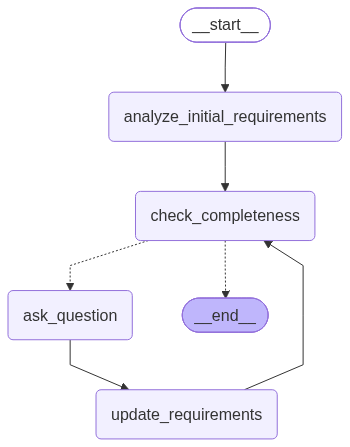

In [85]:
# Visualize the compiled graph topology
from IPython.display import Image, display

try:
    display(Image(clarification_graph.get_graph().draw_mermaid_png()))
except Exception:
    print(clarification_graph.get_graph().draw_ascii())


## 8. Interactive Multi-Turn HITL Execution Test
Tests the full Human-in-the-Loop clarification session.
- Demonstrates how LangGraph pauses at `interrupt()`.
- Reads `state.tasks[0].interrupts[0].value` to retrieve the question.
- Demonstrates resuming via `clarification_graph.invoke(Command(resume=answer), config=config)`.


In [26]:
# # ---------------------------------------------------------------------------
# # Demonstration: Step-by-Step State Inspection & Resume
# # ---------------------------------------------------------------------------
# thread_id = f"test-session-{int(time.time())}"
# config = {"configurable": {"thread_id": thread_id}}

# print(f"--- 1. Starting Session (thread_id: {thread_id}) ---")
# initial_input = {
#     "user_prompt": "We need a real-time IoT delivery fleet tracker for 5,000 trucks. Trucks send telemetry (GPS coordinates, speed, cabin temperature).",
#     "project_context": "Go or Python backend, TimescaleDB, Kafka.",
#     "conversation_log": [],
#     "turn_count": 0,
#     "max_turns": 3,
#     "requirements": RequirementsModel(),
#     "completeness": None,
#     "unresolved_gaps": []
# }

# # Run until the first interrupt
# clarification_graph.invoke(initial_input, config=config)

# # Inspect paused state
# state = clarification_graph.get_state(config)
# print(f"Is graph paused? {'YES' if state.next else 'NO'}")
# print(f"Next Node to execute: {state.next}")

# # Retrieve the question raised by interrupt()
# pending_question = state.tasks[0].interrupts[0].value
# print(f"\n[Agent Question 1]:\n{pending_question}\n")

# # Resume with a simulated response
# print("--- 2. Resuming with Human Answer ---")
# human_response_1 = "Trucks stream telemetry via MQTT into Kafka every 5 seconds. We need alerts triggered within 2 seconds if refrigerated cargo temperature rises above 4°C."

# clarification_graph.invoke(Command(resume=human_response_1), config=config)

# # Check state after resumption
# state = clarification_graph.get_state(config)
# if state.next:
#     next_q = state.tasks[0].interrupts[0].value
#     print(f"\n[Agent Question 2]:\n{next_q}\n")
    
#     # Resume again
#     human_response_2 = "Authentication: Devices authenticate via mutual TLS (mTLS) with X.509 certs. Backend API users authenticate with OAuth2 JWT. Admin and Fleet Dispatcher roles."
#     clarification_graph.invoke(Command(resume=human_response_2), config=config)

# state_final = clarification_graph.get_state(config)
# print(f"\nFinal Graph Status: {'PAUSED' if state_final.next else 'COMPLETED'}")
# print(f"Total Turns: {state_final.values.get('turn_count')}")
# print(f"Functional Requirements Extracted: {len(state_final.values['requirements'].functional_requirements)}")
# for fr in state_final.values['requirements'].functional_requirements:
#     print(f"  • [{fr.req_id}] {fr.title}: {fr.description[:80]}...")


In [11]:
# ---------------------------------------------------------------------------
# Interactive Helper: Chat directly with your Clarification Agent
# ---------------------------------------------------------------------------
def run_interactive_clarification(prompt: str, context: str = None, max_turns: int = 4):
    """Runs a live interactive clarification session in the notebook using input()."""
    t_id = f"interactive-{int(time.time())}"
    cfg = {"configurable": {"thread_id": t_id}}
    
    print("=" * 70)
    print(f"🚀 Launching Clarification Session [Max Turns: {max_turns}]")
    print("=" * 70)
    
    # 1. Seed initial run
    clarification_graph.invoke({
        "user_prompt": prompt,
        "project_context": context,
        "conversation_log": [],
        "turn_count": 0,
        "max_turns": max_turns,
        "requirements": RequirementsModel(),
        "completeness": None,
        "unresolved_gaps": []
    }, config=cfg)
    
    # 2. Conversational loop
    while True:
        curr_state = clarification_graph.get_state(cfg)
        
        # If no next node, graph has completed
        if not curr_state.next:
            print("\n🎉 Clarification Completed!")
            break
            
        # Extract question from interrupt
        question = curr_state.tasks[0].interrupts[0].value
        print(f"\n🤖 Agent (Turn {curr_state.values.get('turn_count', 0) + 1}/{max_turns}):")
        print(f"{question}\n")
        
        # Prompt user in notebook
        user_reply = input("👤 You (type 'exit' to abort): ")
        if user_reply.strip().lower() in ['exit', 'quit']:
            print("Session aborted by user.")
            return None
            
        # Resume the graph with user's reply
        clarification_graph.invoke(Command(resume=user_reply), config=cfg)
        
    final_reqs: RequirementsModel = curr_state.values["requirements"]
    print("\n" + "=" * 70)
    print(f"📋 FINAL REQUIREMENTS MODEL: {final_reqs.project_title}")
    print("=" * 70)
    print(f"Scope: {final_reqs.project_scope}\n")
    print("Actors:", [a.name for a in final_reqs.target_users_and_actors])
    print("Functional Requirements:")
    for fr in final_reqs.functional_requirements:
        print(f"  - [{fr.req_id}] {fr.title} ({fr.priority})")
        for ac in fr.acceptance_criteria:
            print(f"      * {ac}")
    print("Non-Functional Requirements:")
    for nfr in final_reqs.non_functional_requirements:
        print(f"  - [{nfr.category}] {nfr.description} (Metric: {nfr.metric})")
    print("System Constraints:", final_reqs.system_constraints)
    if curr_state.values.get("unresolved_gaps"):
        print("\n⚠️ Unresolved Gaps Carried Forward:", curr_state.values["unresolved_gaps"])
        
    return curr_state.values

# To run a live chat session, simply run:
# session_result = run_interactive_clarification("Build a decentralized peer-to-peer file sharing desktop app")


In [12]:
session_result = run_interactive_clarification("Build an Islamic Quran reading application in flutter")


🚀 Launching Clarification Session [Max Turns: 4]


Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.
Deserializing unregistered type __main__.RequirementsModel from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'RequirementsModel')]
Deserializing unregistered type __main__.CompletenessCheck from checkpoint. This will be blocked in a future version. Set LANGGRAPH_STRICT_MSGPACK=true to block now, or add to allowed_msgpack_modules to allow explicitly: [('__main__', 'CompletenessCheck')]



🔄 [Router] Ambiguities detected (5 gaps). Routing to 'ask_question' (Turn 1/4).

🤖 Agent (Turn 1/4):
Will the application require offline access to the Quranic text, and if so, what is the expected storage mechanism and synchronization strategy for user-specific data like bookmarks and reading progress?


🔄 [Router] Ambiguities detected (5 gaps). Routing to 'ask_question' (Turn 2/4).

🤖 Agent (Turn 2/4):
How will the application handle user authentication and the security of sensitive user-specific data (bookmarks/progress) during transit and at rest?


🔄 [Router] Ambiguities detected (5 gaps). Routing to 'ask_question' (Turn 3/4).

🤖 Agent (Turn 3/4):
What is the defined conflict resolution strategy when a user's local reading progress or bookmarks differ from the data stored on the backend during a synchronization event?


🔄 [Router] Ambiguities detected (5 gaps). Routing to 'ask_question' (Turn 4/4).

🤖 Agent (Turn 4/4):
What specific authentication protocol (e.g., OAuth2/OpenID Co

# Phase 2: Standalone Generation Subgraph (SRS Subagent)
This section implements **Phase 2** of `SRS_Subgraph_Implementation_Plan.md`.
It builds a parallelized document drafting engine, automated diagram synthesizer with compiler-in-the-loop repair, and deterministic IEEE 830 document assembler.

### Key Architectural Invariants:
1. **State Isolation**: Operates on a frozen `RequirementsModel` with zero access to conversational turn state or `interrupt()`.
2. **Parallel Fan-Out**: Uses LangGraph's `Send()` API to draft sections concurrently.
3. **Compiler-in-the-Loop Repair**: Diagrams are validated against real syntax parsers with a bounded repair cycle (max 3 attempts).
4. **Deterministic Assembly**: Non-LLM document assembly prevents hallucinated content modification during final stitching.


In [13]:
# ---------------------------------------------------------------------------
# Phase 2 Schemas: Document Outline, Sections, Diagrams, & GenerationState
# ---------------------------------------------------------------------------

class OutlineSection(BaseModel):
    section_id: str = Field(description="Hierarchical section ID e.g. '1.0', '2.1'")
    title: str = Field(description="Section heading title")
    purpose_and_guidance: str = Field(description="Specific instructions for the generative worker drafting this section")
    subsections: list["OutlineSection"] = Field(default_factory=list)

class DocOutline(BaseModel):
    document_title: str = Field(description="Title of the SRS document")
    target_audience: str = Field(description="Intended audience (e.g. Software Engineers, QA, System Architects)")
    sections: list[OutlineSection] = Field(description="Hierarchical list of outline sections")

class SectionDraft(BaseModel):
    section_id: str = Field(description="Section ID matching the outline e.g. '1.0'")
    title: str = Field(description="Section title")
    content_markdown: str = Field(description="Drafted markdown content for this section")

class DiagramSpec(BaseModel):
    diagram_id: str = Field(description="Unique identifier e.g. 'diag-001'")
    title: str = Field(description="Descriptive diagram title")
    diagram_type: Literal["architecture", "sequence", "erd", "state", "flowchart"] = Field(
        description="Type of architectural diagram"
    )
    syntax_format: Literal["mermaid", "plantuml"] = Field(
        default="mermaid",
        description="Syntax format of the diagram"
    )
    source_code: str = Field(default="", description="Mermaid or PlantUML source code")
    target_section_id: str = Field(description="Which outline section this diagram belongs to (e.g. '2.1')")
    repair_attempts: int = Field(default=0, description="Number of syntax repair cycles attempted")
    last_error: Optional[str] = Field(default=None, description="Last compiler error message if syntax validation failed")

class ValidatedDiagram(BaseModel):
    diagram_id: str
    title: str
    syntax_format: str
    source_code: str
    target_section_id: str
    is_valid: bool = Field(description="True if compiled without syntax errors")
    svg_file_path: Optional[str] = Field(default=None, description="Local path to rendered SVG file if compiled")
    rendered_svg_content: Optional[str] = Field(default=None, description="Raw SVG string content")
    repair_attempts: int = Field(default=0)
    review_warning: Optional[str] = Field(default=None, description="Warning note if repair attempts were exhausted")

# ---------------------------------------------------------------------------
# Generation Subgraph State Schema
# ---------------------------------------------------------------------------
class GenerationState(TypedDict):
    requirements: RequirementsModel
    unresolved_gaps: list[str]
    outline: Optional[DocOutline]
    # operator.add enables parallel worker aggregation from Send()
    section_drafts: Annotated[list[SectionDraft], operator.add]
    diagram_specs: list[DiagramSpec]
    validated_diagrams: Annotated[list[ValidatedDiagram], operator.add]
    final_document: Optional[str]
    diagram_manifest: list[dict]

print("✓ Phase 2 Data Models & GenerationState successfully defined.")


✓ Phase 2 Data Models & GenerationState successfully defined.


In [14]:
import ast


def extract_llm_content(response) -> str:
    """
    Extract only the actual text content from an LLM response.

    Handles:
    - Plain text strings
    - String representations of Python lists/dicts
    - Lists of content blocks
    - Dictionaries
    - LangChain-style objects
    - Nested content
    - Content blocks with metadata/extras

    Example input:
        "[{'type': 'text', 'text': '## Introduction', 'extras': {...}}]"

    Returns:
        "## Introduction"
    """

    if response is None:
        return ""

    # ---------------------------------------------------------
    # 1. If it's already a string
    # ---------------------------------------------------------
    if isinstance(response, str):

        text = response.strip()

        if not text:
            return ""

        # Try to parse strings that contain Python
        # representations of lists/dicts.
        #
        # Example:
        # "[{'type': 'text', 'text': 'Hello'}]"
        try:
            parsed = ast.literal_eval(text)

            # Only use the parsed value if it actually
            # became a list/dict/tuple.
            if isinstance(parsed, (list, tuple, dict)):
                return extract_llm_content(parsed)

        except (ValueError, SyntaxError):
            # It is normal text, not a serialized Python object.
            pass

        # It's already clean text
        return response

    # ---------------------------------------------------------
    # 2. List / tuple
    # ---------------------------------------------------------
    if isinstance(response, (list, tuple)):

        text_parts = []

        for item in response:

            # Content block:
            # {"type": "text", "text": "..."}
            if isinstance(item, dict):

                if item.get("type") == "text" and "text" in item:
                    extracted = extract_llm_content(item["text"])

                    if extracted:
                        text_parts.append(extracted)

                elif "text" in item:
                    extracted = extract_llm_content(item["text"])

                    if extracted:
                        text_parts.append(extracted)

                elif "content" in item:
                    extracted = extract_llm_content(item["content"])

                    if extracted:
                        text_parts.append(extracted)

            else:
                extracted = extract_llm_content(item)

                if extracted:
                    text_parts.append(extracted)

        return "\n".join(text_parts)

    # ---------------------------------------------------------
    # 3. Dictionary
    # ---------------------------------------------------------
    if isinstance(response, dict):

        # {"type": "text", "text": "..."}
        if response.get("type") == "text" and "text" in response:
            return extract_llm_content(response["text"])

        # {"text": "..."}
        if "text" in response:
            return extract_llm_content(response["text"])

        # {"content": "..."}
        if "content" in response:
            return extract_llm_content(response["content"])

        # Other common wrappers
        for key in ("output", "message", "response", "data"):

            if key in response:
                extracted = extract_llm_content(response[key])

                if extracted:
                    return extracted

        return ""

    # ---------------------------------------------------------
    # 4. Objects with .content
    # ---------------------------------------------------------
    if hasattr(response, "content"):

        try:
            content = response.content

            if content is not response:
                extracted = extract_llm_content(content)

                if extracted:
                    return extracted

        except Exception:
            pass

    # ---------------------------------------------------------
    # 5. Objects with .text
    # ---------------------------------------------------------
    if hasattr(response, "text"):

        try:
            text = response.text

            if text is not response:
                extracted = extract_llm_content(text)

                if extracted:
                    return extracted

        except Exception:
            pass

    # ---------------------------------------------------------
    # 6. Fallback
    # ---------------------------------------------------------
    return str(response)

## 2. Document Outline Generation Node (`generate_outline`)
Constructs an IEEE 830-compliant document outline (`DocOutline`) tailored to the extracted requirements.
- Uses `.with_structured_output(DocOutline)` for deterministic schema generation.
- Implements **Thin-Input Resiliency**: gracefully handles incomplete specifications and unresolved ambiguities by planning explicit gap-analysis sections.
- Defines clear `purpose_and_guidance` for each section, which serves as the blueprint for subsequent parallel workers.


In [15]:
# ---------------------------------------------------------------------------
# Node: generate_outline
# ---------------------------------------------------------------------------
OUTLINE_GENERATION_SYSTEM_PROMPT = """You are a Principal Technical Writer and Software Architect designing an IEEE 830-compliant Software Requirements Specification (SRS).
Your task is to review the structured RequirementsModel and any unresolved gaps, and generate a comprehensive, professional document outline (DocOutline).

Standard IEEE 830 Sections to Include:
1. "1.0 Introduction" (Purpose, Scope, Intended Audience, Document Conventions)
2. "2.0 Overall Description" (Product Perspective, User Classes & Actors, Operating Environment, Design Constraints, Assumptions & Dependencies)
3. "3.0 System Features & Functional Requirements" (Grouped by major feature or user workflow with clear functional breakdown)
4. "4.0 External Interface Requirements" (User, Hardware, Software/API, and Communication Interfaces)
5. "5.0 Non-Functional & Quality Attributes" (Performance, Security/Auth, Reliability, Scalability, and Compliance)

Thin-Input & Gap Resiliency Rules:
1. If `unresolved_gaps` contains items, append a dedicated section: "6.0 Unresolved Requirements & Ambiguity Register" to track open items.
2. In `purpose_and_guidance` for each section, provide specific, prescriptive instructions detailing exactly which actors, functional requirements, or constraints from the model should be drafted in that section.
3. Keep the outline to 5–7 major sections to allow clean parallel worker drafting.
"""

def generate_outline(state: GenerationState) -> dict:
    reqs: RequirementsModel = state["requirements"]
    gaps = state.get("unresolved_gaps", [])
    
    # Format requirements model as context for the outline generator
    reqs_summary = f"""Project Title: {reqs.project_title}
Project Scope: {reqs.project_scope}

Target Actors:
{json.dumps([a.model_dump() for a in reqs.target_users_and_actors], indent=2)}

Functional Requirements ({len(reqs.functional_requirements)} total):
{json.dumps([fr.model_dump() for fr in reqs.functional_requirements], indent=2)}

Non-Functional Requirements:
{json.dumps([nfr.model_dump() for nfr in reqs.non_functional_requirements], indent=2)}

System Constraints:
{json.dumps(reqs.system_constraints, indent=2)}

Assumptions & Dependencies:
{json.dumps(reqs.assumptions_and_dependencies, indent=2)}

Unresolved Ambiguity Register ({len(gaps)} items):
{json.dumps(gaps, indent=2)}
"""

    prompt = f"""Generate the formal IEEE 830 DocOutline based on the following requirements specification:

{reqs_summary}
"""
    
    structured_llm = llm.with_structured_output(DocOutline)
    outline: DocOutline = structured_llm.invoke([
        SystemMessage(content=OUTLINE_GENERATION_SYSTEM_PROMPT),
        HumanMessage(content=prompt)
    ])
    
    print(f"✓ Outline generated: '{outline.document_title}' ({len(outline.sections)} major sections)")
    for sec in outline.sections:
        print(f"   [{sec.section_id}] {sec.title}")
        
    return {
        "outline": outline
    }

print("✓ generate_outline node defined.")


✓ generate_outline node defined.


In [16]:
# ---------------------------------------------------------------------------
# Isolated Unit Test for generate_outline
# ---------------------------------------------------------------------------
# We test using the final requirements model generated from Phase 1,
# or fall back to a realistic mock if running this cell standalone.

sample_reqs = None
sample_gaps = []

if 'session_result' in globals() and session_result and "requirements" in session_result:
    sample_reqs = session_result["requirements"]
    sample_gaps = session_result.get("unresolved_gaps", [])
    print(f"Using requirements from Phase 1 session: '{sample_reqs.project_title}'")
else:
    # Standalone mock fixture
    sample_reqs = RequirementsModel(
        project_title="Cloud Native Distributed Cache",
        project_scope="A distributed in-memory key-value caching service with Raft consensus and LRU eviction.",
        target_users_and_actors=[
            Actor(name="Application Client", description="Microservices reading and writing cache keys via gRPC"),
            Actor(name="Cluster Administrator", description="DevOps managing node cluster configuration")
        ],
        functional_requirements=[
            FunctionalRequirement(
                req_id="FR-001",
                title="Key-Value CRUD Operations",
                description="Support Get, Set, Delete, and Compare-and-Swap operations via gRPC.",
                priority="Must Have",
                acceptance_criteria=["p99 latency < 5ms for Get operations", "Atomic CAS semantics"]
            ),
            FunctionalRequirement(
                req_id="FR-002",
                title="Cluster Consensus & Node Membership",
                description="Elect cluster leaders and replicate log entries via Raft consensus.",
                priority="Must Have",
                acceptance_criteria=["Survive loss of minority nodes without data loss"]
            )
        ],
        non_functional_requirements=[
            NonFunctionalRequirement(category="Performance", description="High throughput caching", metric="100k QPS per node"),
            NonFunctionalRequirement(category="Security", description="mTLS for node-to-node and client communication")
        ],
        system_constraints=["Written in Go or Rust", "Linux container deployment"],
        assumptions_and_dependencies=["Reliable private network interconnect"]
    )
    sample_gaps = ["Data encryption at rest requirements unspecified", "Maximum cluster size undefined"]
    print(f"Using mock requirements fixture: '{sample_reqs.project_title}'")

test_gen_state: GenerationState = {
    "requirements": sample_reqs,
    "unresolved_gaps": sample_gaps,
    "outline": None,
    "section_drafts": [],
    "diagram_specs": [],
    "validated_diagrams": [],
    "final_document": None,
    "diagram_manifest": []
}

test_outline_result = generate_outline(test_gen_state)
outline_obj: DocOutline = test_outline_result["outline"]

print("\nSample Section Guidance:")
print(f"Section 1: {outline_obj.sections[0].title}")
print(f"Guidance : {outline_obj.sections[0].purpose_and_guidance[:150]}...")


Using requirements from Phase 1 session: 'Islamic Quran Reading Application'
✓ Outline generated: 'Software Requirements Specification for Islamic Quran Reading Application' (5 major sections)
   [1.0] Introduction
   [2.0] Overall Description
   [3.0] System Features & Functional Requirements
   [4.0] External Interface Requirements
   [5.0] Non-Functional & Quality Attributes

Sample Section Guidance:
Section 1: Introduction
Guidance : Define the purpose of the Quran Reading Application as a cross-platform mobile tool. Scope the document to the Flutter-based mobile client and its int...


In [17]:
for outline in outline_obj.sections:
    print("\nSample Section Guidance:")
    print(f"Section 1: {outline.title}")
    print(f"Guidance : {outline.purpose_and_guidance}...")



Sample Section Guidance:
Section 1: Introduction
Guidance : Define the purpose of the Quran Reading Application as a cross-platform mobile tool. Scope the document to the Flutter-based mobile client and its interaction with the Backend Synchronization Service. List conventions including the use of IEEE 830 standards and priority levels (Must Have/Should Have)....

Sample Section Guidance:
Section 1: Overall Description
Guidance : Describe the product as an offline-first mobile application. Define the 'Quran Reader' and 'Backend Synchronization Service' as primary actors. Detail constraints: Flutter framework, cross-platform deployment, and local bundling of Quranic text. List assumptions regarding the Tanzil dataset and backend availability....

Sample Section Guidance:
Section 1: System Features & Functional Requirements
Guidance : Group requirements into logical workflows: 1. Reading Experience (FR-001, FR-002), 2. Data Management (FR-003, FR-004), and 3. Security (FR-005). Ensure e

## 3. Parallel Section Drafting Workers (`fan_out_sections` & `generate_section`)
Implements parallel section drafting via LangGraph's `Send()` API:
- `fan_out_sections`: Conditional edge that inspects `state["outline"].sections` and returns a list of `Send()` objects targeting `generate_section`.
- `generate_section`: Worker node that drafts comprehensive, production-grade IEEE 830 Markdown content for its assigned section.
- Uses `operator.add` reducer to aggregate drafts asynchronously without thread collisions or state clobbering.

In [18]:
# ---------------------------------------------------------------------------
# Section Worker Input Schema & Router
# ---------------------------------------------------------------------------
from langgraph.types import Send
from httpx import RemoteProtocolError, ConnectError, ReadTimeout


class SectionWorkerInput(TypedDict):
    section_id: str
    title: str
    purpose: str
    requirements: RequirementsModel
    unresolved_gaps: list[str]
    outline_summary: list[str]

# ---------------------------------------------------------------------------
# Conditional Edge: fan_out_sections
# ---------------------------------------------------------------------------
def fan_out_sections(state: GenerationState) -> list[Send]:
    outline: Optional[DocOutline] = state.get("outline")
    if not outline or not outline.sections:
        print("⚠️ [Fan-Out] No sections found in outline to fan out.")
        return []
        
    sends = []
    outline_titles = [f"[{sec.section_id}] {sec.title}" for sec in outline.sections]
    
    for sec in outline.sections:
        payload: SectionWorkerInput = {
            "section_id": sec.section_id,
            "title": sec.title,
            "purpose": sec.purpose_and_guidance,
            "requirements": state["requirements"],
            "unresolved_gaps": state.get("unresolved_gaps", []),
            "outline_summary": outline_titles
        }
        sends.append(Send("generate_section", payload))
        
    print(f"🚀 [Fan-Out] Dispatched {len(sends)} parallel section drafting workers.")
    return sends

# ---------------------------------------------------------------------------
# Node: generate_section (Parallel Generative Worker with Network Resilience)
# ---------------------------------------------------------------------------
SECTION_DRAFTING_SYSTEM_PROMPT = """You are a Principal Software Architect and Lead Technical Author drafting a section of an IEEE 830 Software Requirements Specification (SRS).

Your Task:
Draft the complete, authoritative Markdown content for your assigned section based ONLY on the provided RequirementsModel and section guidance.

Drafting Standards:
1. Professional Markdown: Use clear headings (`##`, `###`), structured comparison tables, numbered lists, and bullet points.
2. In-Depth Coverage: If drafting functional requirements, write out full descriptions, actors, priority, and bulleted acceptance criteria for each requirement.
3. Traceability: Refer to requirements by their explicit IDs (e.g., `[FR-001]`, `[NFR-001]`).
4. Cross-Referencing: You are given the full document outline so you can accurately reference other sections (e.g. "See Section 4.0 for API specifications").
5. Architectural Fidelity: DO NOT invent conflicting technical details. Stay aligned with the project scope and constraints.
6. Return ONLY the Markdown content for this specific section. Do NOT duplicate the top-level document title.
"""

# ---------------------------------------------------------------------------
# 3. Resilient LLM Invoker
# ---------------------------------------------------------------------------
def safe_llm_invoke(messages: list, max_retries: int = 4, base_delay: float = 2.0):
    """Invokes LLM with exponential backoff for transient network errors."""
    for attempt in range(1, max_retries + 1):
        try:
            return llm.invoke(messages)   # <-- now uses global diagram_llm
        except (RemoteProtocolError, ConnectError, ReadTimeout, Exception) as exc:
            if attempt == max_retries:
                print(f"❌ [Network Error] Max retries ({max_retries}) exhausted: {exc}")
                raise exc
            sleep_time = base_delay * (2 ** (attempt - 1))
            print(f"⚠️ [Network Glitch] Retrying in {sleep_time:.1f}s (Attempt {attempt}/{max_retries})...")
            time.sleep(sleep_time)

def _extract_text_from_response(response) -> str: 
    """Safely extracts text content from string or AIMessage.""" 
    if hasattr(response, "content"): 
        return str(response.content) 
    return str(response) 

response_testing = []

def generate_section(input_payload: SectionWorkerInput) -> dict:
    sec_id = input_payload["section_id"]
    title = input_payload["title"]
    guidance = input_payload["purpose"]
    reqs: RequirementsModel = input_payload["requirements"]
    gaps = input_payload.get("unresolved_gaps", [])
    outline_summary = input_payload.get("outline_summary", [])
    
    reqs_context = f"""Project: {reqs.project_title}
Scope: {reqs.project_scope}

Target Actors:
{[a.name + ': ' + a.description for a in reqs.target_users_and_actors]}

Functional Requirements:
{json.dumps([fr.model_dump() for fr in reqs.functional_requirements], indent=2)}

Non-Functional Requirements:
{json.dumps([nfr.model_dump() for nfr in reqs.non_functional_requirements], indent=2)}

Constraints:
{reqs.system_constraints}

Assumptions & Dependencies:
{reqs.assumptions_and_dependencies}

Unresolved Ambiguities:
{gaps}
"""

    prompt = f"""Assigned Section: [{sec_id}] {title}
Section Guidance & Objectives:
{guidance}

Full Document Structure for Cross-Referencing:
{outline_summary}

System Requirements Model:
{reqs_context}

Draft the complete Markdown content for section [{sec_id}] {title} now."""

    # Using safe_llm_invoke to guard against transient connection drops
    response = safe_llm_invoke([
        SystemMessage(content=SECTION_DRAFTING_SYSTEM_PROMPT),
        HumanMessage(content=prompt)
    ])
    unclean_draft_content = _extract_text_from_response(response).strip()
    draft_content = extract_llm_content(unclean_draft_content).strip()

    
    draft = SectionDraft(
        section_id=sec_id,
        title=title,
        content_markdown=draft_content
    )
    
    print(f"  ✓ Completed draft for section [{sec_id}] {title} ({len(draft.content_markdown)} chars)")
    
    return {
        "section_drafts": [draft]
    }

print("✓ Resilient fan_out_sections router & generate_section worker defined.")


✓ Resilient fan_out_sections router & generate_section worker defined.


In [19]:
# ---------------------------------------------------------------------------
# Isolated Unit Test for generate_section Worker
# ---------------------------------------------------------------------------
# Pick the first section from our test outline generated in Step 2
test_section = outline_obj.sections[0]

test_worker_payload: SectionWorkerInput = {
    "section_id": test_section.section_id,
    "title": test_section.title,
    "purpose": test_section.purpose_and_guidance,
    "requirements": sample_reqs,
    "unresolved_gaps": sample_gaps,
    "outline_summary": [f"[{s.section_id}] {s.title}" for s in outline_obj.sections]
}

print(f"Testing worker on section: [{test_section.section_id}] {test_section.title}...")
worker_output = generate_section(test_worker_payload)
draft_result: SectionDraft = worker_output["section_drafts"][0]

print("\n" + "=" * 60)
print(f"DRAFT PREVIEW: [{draft_result.section_id}] {draft_result.title}")
print("=" * 60)
print(draft_result.content_markdown[:600] + "\n\n... [truncated] ...")


Testing worker on section: [1.0] Introduction...
  ✓ Completed draft for section [1.0] Introduction (3273 chars)

DRAFT PREVIEW: [1.0] Introduction
## 1.0 Introduction

### 1.1 Purpose
The purpose of this Software Requirements Specification (SRS) is to define the functional and non-functional requirements for the Islamic Quran Reading Application. This document serves as the primary reference for stakeholders, developers, and quality assurance teams to ensure the delivery of a high-quality, cross-platform mobile tool designed to facilitate the reading, navigation, and study of the Quran.

### 1.2 Scope
This document covers the development of the mobile client application built using the **Flutter framework**, targeting both iOS and Androi

... [truncated] ...


In [20]:
# print(draft_result.content_markdown)
print(extract_llm_content(draft_result.content_markdown))
# type(draft_result.content_markdown)

## 1.0 Introduction

### 1.1 Purpose
The purpose of this Software Requirements Specification (SRS) is to define the functional and non-functional requirements for the Islamic Quran Reading Application. This document serves as the primary reference for stakeholders, developers, and quality assurance teams to ensure the delivery of a high-quality, cross-platform mobile tool designed to facilitate the reading, navigation, and study of the Quran.

### 1.2 Scope
This document covers the development of the mobile client application built using the **Flutter framework**, targeting both iOS and Android platforms. The scope includes:
*   The local rendering and management of Quranic text.
*   User authentication and secure local data management.
*   Interaction with the **Backend Synchronization Service** for cloud-based data persistence.

Exclusions: This document does not cover the internal architecture or implementation details of the Backend Synchronization Service, except where it pertains

In [72]:
draft_result.content_markdown

'[{\'type\': \'text\', \'text\': "## 1.0 Introduction\\n\\n### 1.1 Purpose\\nThe purpose of this Software Requirements Specification (SRS) is to define the functional and non-functional requirements for the **Cloud Native Distributed Cache**, a high-performance, in-memory key-value store. This document serves as the primary reference for the design, implementation, and verification of the system, ensuring consistency across the distributed architecture.\\n\\n### 1.2 Scope\\nThis document covers the development of a distributed caching service utilizing the Raft consensus algorithm for data consistency and an LRU (Least Recently Used) eviction policy for memory management. The scope is strictly limited to:\\n*   The gRPC-based communication layer for client-server and inter-node interaction.\\n*   The implementation of core CRUD operations as defined in [Section 3.0].\\n*   Deployment configurations for Linux-based containerized environments.\\n\\nOut of scope for this version are persi

## 4. Visual Architecture Diagram Planner (`determine_diagrams` & `fan_out_diagrams`)
Analyzes the system requirements and drafted sections to plan appropriate architectural diagrams:
- Plans 2 to 4 essential visual models (Architecture/C4, Sequence flow, ERD, or State Machine).
- Assigns each diagram a unique `diagram_id`, target outline section (`target_section_id`), and syntax format (`mermaid`).
- `fan_out_diagrams`: Conditional edge dispatching parallel synthesis tasks via `Send("generate_diagram", ...)`.


In [21]:
# ---------------------------------------------------------------------------
# Schema Wrapper for Structured Output
# ---------------------------------------------------------------------------
class PlannedDiagrams(BaseModel):
    diagrams: list[DiagramSpec] = Field(
        description="List of 2 to 4 essential architectural diagrams needed for the SRS"
    )

# ---------------------------------------------------------------------------
# Node: determine_diagrams
# ---------------------------------------------------------------------------
DIAGRAM_PLANNER_SYSTEM_PROMPT = """You are a Principal Software Solutions Architect determining the visual modeling specifications for an IEEE 830 SRS document.

Your Objective:
Review the system requirements and plan 2 to 6 essential architectural diagrams that visually communicate the system's core design.

Standard Architectural Diagram Archetypes:
1. High-Level Architecture / System Context (`diagram_type="architecture"`):
   - Shows user actors, microservices/subsystems, and external integrations (APIs, databases).
   - Target Section: Typically Section 2.0 (Overall Description).
2. Core Business Workflow (`diagram_type="sequence"`):
   - Illustrates the critical multi-actor transaction or request-response lifecycle.
   - Target Section: Typically Section 3.0 (System Features & Functional Requirements).
3. Domain Data Model (`diagram_type="erd"`):
   - Outlines primary database entities, relationships, and key attributes.
   - Target Section: Typically Section 3.0 or Section 4.0.
4. Lifecycle State Machine (`diagram_type="state"`):
   - Visualizes entity status transitions (e.g. Order status, Ride status, Auth lifecycle).
   - Target Section: Typically Section 3.0.

Guidelines:
- Default `syntax_format="mermaid"` (standard Markdown renderable).
- Leave `source_code=""` (the downstream diagram worker will write the actual code).
- Target valid `target_section_id` values from the document outline.
"""


def determine_diagrams(state: GenerationState) -> dict:
    reqs: RequirementsModel = state["requirements"]
    outline: Optional[DocOutline] = state.get("outline")
    
    sections_info = []
    if outline:
        sections_info = [f"[{sec.section_id}] {sec.title}" for sec in outline.sections]
        
    context = f"""System Title: {reqs.project_title}
Scope: {reqs.project_scope}
Actors: {[a.name for a in reqs.target_users_and_actors]}
Core Functional Requirements:
{[f"{fr.req_id}: {fr.title} ({fr.priority})" for fr in reqs.functional_requirements]}
Available Outline Sections for Placement:
{sections_info}
"""

    prompt = f"""Analyze this system specification and determine the 2 to 6 most critical architectural diagrams needed for the SRS:

{context}
"""
    
    structured_planner = llm.with_structured_output(PlannedDiagrams)
    planned: PlannedDiagrams = structured_planner.invoke([
        SystemMessage(content=DIAGRAM_PLANNER_SYSTEM_PROMPT),
        HumanMessage(content=prompt)
    ])
    
    print(f"\n📊 [Diagram Planner] Planned {len(planned.diagrams)} architectural diagrams:")
    for diag in planned.diagrams:
        print(f"   • [{diag.diagram_id}] {diag.title} (Type: {diag.diagram_type} | Target Section: {diag.target_section_id})")
        
    return {
        "diagram_specs": planned.diagrams
    }

# ---------------------------------------------------------------------------
# Conditional Edge: fan_out_diagrams
# ---------------------------------------------------------------------------
class DiagramWorkerInput(TypedDict):
    diagram_spec: DiagramSpec
    requirements: RequirementsModel

def fan_out_diagrams(state: GenerationState) -> list[Send]:
    specs = state.get("diagram_specs", [])
    if not specs:
        print("⚠️ [Fan-Out Diagrams] No diagram specs to dispatch.")
        return []
        
    sends = []
    for spec in specs:
        payload: DiagramWorkerInput = {
            "diagram_spec": spec,
            "requirements": state["requirements"]
        }
        sends.append(Send("generate_diagram", payload))
        
    print(f"🚀 [Fan-Out Diagrams] Dispatched {len(sends)} parallel diagram generation workers.")
    return sends

print("✓ determine_diagrams node & fan_out_diagrams router defined.")


✓ determine_diagrams node & fan_out_diagrams router defined.


In [22]:
# ---------------------------------------------------------------------------
# Isolated Unit Test for determine_diagrams
# ---------------------------------------------------------------------------
test_diagram_state: GenerationState = {
    "requirements": sample_reqs,
    "unresolved_gaps": sample_gaps,
    "outline": outline_obj,
    "section_drafts": [],
    "diagram_specs": [],
    "validated_diagrams": [],
    "final_document": None,
    "diagram_manifest": []
}

diagram_plan_result = determine_diagrams(test_diagram_state)
planned_specs = diagram_plan_result["diagram_specs"]

print("\nFirst Planned Diagram Spec:")
print(f"ID      : {planned_specs[0].diagram_id}")
print(f"Title   : {planned_specs[0].title}")
print(f"Type    : {planned_specs[0].diagram_type}")
print(f"Format  : {planned_specs[0].syntax_format}")
print(f"Target  : Section {planned_specs[0].target_section_id}")



📊 [Diagram Planner] Planned 4 architectural diagrams:
   • [diag-001] System Context Architecture (Type: architecture | Target Section: 2.0)
   • [diag-002] Data Synchronization Workflow (Type: sequence | Target Section: 3.0)
   • [diag-003] User Data and Quran Content Entity Model (Type: erd | Target Section: 3.0)
   • [diag-004] Authentication and Session State Machine (Type: state | Target Section: 3.0)

First Planned Diagram Spec:
ID      : diag-001
Title   : System Context Architecture
Type    : architecture
Format  : mermaid
Target  : Section 2.0


## 5. Diagram Synthesizer, Subprocess Validator & Self-Healing Repair Loop
Implements isolated architectural diagram code synthesis with a compiler-in-the-loop repair cycle:
- `SubprocessCompilerRunner`: Validates Mermaid/PlantUML source code using local CLI compilers with a strict execution timeout and robust syntax validation fallback.
- `generate_diagram_code`: Dual-mode LLM synthesizer supporting initial generation and targeted error repair.
- `generate_diagram`: Worker node executing the bounded self-healing loop (up to 3 repair cycles).
- Returns aggregated `validated_diagrams` via LangGraph's `operator.add` reducer.


In [23]:
# ---------------------------------------------------------------------------
# 1. Imports & Global Setup
# ---------------------------------------------------------------------------
import os
import re
import ast
import time
import subprocess
import tempfile
from typing import Optional
from langchain_core.messages import SystemMessage, HumanMessage
from httpx import RemoteProtocolError, ConnectError, ReadTimeout
from langchain_openrouter import ChatOpenRouter

# ---------------------------------------------------------------------------
# 2. LLM Initialization (replace with your actual API key / config)
# ---------------------------------------------------------------------------
# Make sure you have set your OpenRouter API key in environment or directly.
# openrouter_api_key = "your-api-key-here"
openrouter_api_key = (env_vals.get("OPENROUTER_API_KEY") or os.getenv("OPENROUTER_API_KEY") or "").strip().strip('"').strip("'")
print("OpenRouter key loaded" if openrouter_api_key else "OpenRouter key missing")

diagram_llm = ChatOpenRouter(
    model="nvidia/nemotron-3.5-lightning:free",
    temperature=0,
    api_key=openrouter_api_key,
    request_timeout=280.0,
    max_retries=3
)
# For now we'll define a placeholder; you should uncomment and adjust.
# diagram_llm = None  # Replace with actual instantiation

# ---------------------------------------------------------------------------
# 3. Resilient LLM Invoker
# ---------------------------------------------------------------------------
def safe_llm_invoke(messages: list, max_retries: int = 4, base_delay: float = 2.0):
    """Invokes LLM with exponential backoff for transient network errors."""
    for attempt in range(1, max_retries + 1):
        try:
            return llm.invoke(messages)   # <-- now uses global diagram_llm
        except (RemoteProtocolError, ConnectError, ReadTimeout, Exception) as exc:
            if attempt == max_retries:
                print(f"❌ [Network Error] Max retries ({max_retries}) exhausted: {exc}")
                raise exc
            sleep_time = base_delay * (2 ** (attempt - 1))
            print(f"⚠️ [Network Glitch] Retrying in {sleep_time:.1f}s (Attempt {attempt}/{max_retries})...")
            time.sleep(sleep_time)

# ---------------------------------------------------------------------------
# 4. Unified Mermaid Code Extractor
# ---------------------------------------------------------------------------
def extract_mermaid_code(response) -> str:
    """
    Extracts raw Mermaid code from an LLM response, handling:
      - plain string content
      - list of content blocks (e.g. OpenAI multimodal)
      - stringified list (e.g. '[{"type": "text", "text": "..."}]')
    Also strips markdown code fences if present.
    """
    content = response.content if hasattr(response, "content") else str(response)

    # Case 1: already a list of blocks
    if isinstance(content, list):
        texts = []
        for part in content:
            if isinstance(part, dict) and part.get("type") == "text":
                texts.append(part.get("text", ""))
        code = "\n".join(texts).strip()
    # Case 2: string that looks like a list literal
    elif isinstance(content, str) and content.strip().startswith('[') and content.strip().endswith(']'):
        try:
            data = ast.literal_eval(content)
            if isinstance(data, list):
                texts = [item.get('text', '') for item in data if isinstance(item, dict)]
                code = "\n".join(texts).strip()
            else:
                code = content
        except Exception:
            code = content
    else:
        code = content.strip()

    # Remove markdown code fences if present
    if code.startswith("```"):
        code = re.sub(r"^```(?:mermaid)?\n", "", code)
        code = re.sub(r"\n```$", "", code).strip()
    return code

# ---------------------------------------------------------------------------
# 5. Subprocess Compiler Runner & Syntax Validator
# ---------------------------------------------------------------------------
class SubprocessCompilerRunner:
    """Validates Mermaid and PlantUML diagrams using subprocess CLIs or static syntax parsers."""
    
    @staticmethod
    def validate_mermaid(source_code: str) -> tuple[bool, Optional[str], Optional[str]]:
        """
        Validates Mermaid syntax.
        Returns: (is_valid, svg_content_or_None, error_message_or_None)
        """
        clean_code = source_code.strip()
        # Remove markdown code fences if present
        if clean_code.startswith("```"):
            clean_code = re.sub(r"^```(?:mermaid)?\n", "", clean_code)
            clean_code = re.sub(r"\n```$", "", clean_code).strip()
            
        # 1. Attempt Subprocess execution with mmdc if installed
        in_path = None
        out_path = None
        try:
            with tempfile.NamedTemporaryFile(suffix=".mmd", delete=False, mode="w", encoding="utf-8") as f_in:
                f_in.write(clean_code)
                in_path = f_in.name
                
            out_path = in_path.replace(".mmd", ".svg")
            
            result = subprocess.run(
                ["mmdc", "-i", in_path, "-o", out_path],
                capture_output=True,
                text=True,
                timeout=15,
                shell=True
            )
            
            if result.returncode == 0 and os.path.exists(out_path):
                with open(out_path, "r", encoding="utf-8") as f_out:
                    svg_content = f_out.read()
                return True, svg_content, None
        except Exception:
            pass
        finally:
            # Clean up temporary files
            if in_path and os.path.exists(in_path):
                try:
                    os.remove(in_path)
                except OSError:
                    pass
            if out_path and os.path.exists(out_path):
                try:
                    os.remove(out_path)
                except OSError:
                    pass

        # 2. Strict Static Syntax Validator (Fallback)
        valid_headers = [
            "graph", "flowchart", "sequencediagram", "classdiagram",
            "erdiagram", "statediagram", "statediagram-v2", "gitgraph", "pie"
        ]
        
        lines = [line.strip() for line in clean_code.split("\n") if line.strip() and not line.strip().startswith("%%")]
        if not lines:
            return False, None, "Mermaid diagram code is empty."
            
        header = lines[0].lower().replace(" ", "")
        has_valid_header = any(header.startswith(vh.replace(" ", "")) for vh in valid_headers)
        if not has_valid_header:
            return False, None, f"Invalid Mermaid diagram header '{lines[0]}'. Must start with 'graph TD', 'flowchart TD', 'sequenceDiagram', 'erDiagram', or 'stateDiagram-v2'."
            
        for i, line in enumerate(lines[1:], start=2):
            unquoted_brackets = re.findall(r'\[([^"\]]*\([^"\]]*\)[^"\]]*)\]', line)
            if unquoted_brackets:
                return False, None, f"Syntax Error on line {i}: '{line}'. Node labels with parentheses must be enclosed in double quotes: e.g. [\"Label (Details)\"]."
                
        return True, f"<svg><!-- Rendered Mermaid: {lines[0]} --></svg>", None

# ---------------------------------------------------------------------------
# 6. Diagram Code Synthesizer (Initial Pass & Targeted Repair Pass)
# ---------------------------------------------------------------------------
DIAGRAM_GENERATION_SYSTEM_PROMPT = """You are an Expert Systems Architecture Visualizer specializing in strict Mermaid.js syntax.

Your Task:
Generate production-ready, syntactically clean Mermaid code for the requested diagram.

Strict Mermaid Syntax Rules:
1. ONLY return the raw Mermaid diagram source code. Do NOT wrap in markdown code fences (no ```mermaid). Do NOT add explanatory text.
2. For flowchart/graph:
   - Always start with `flowchart TD` or `flowchart LR`.
   - Node text containing parentheses, commas, brackets, or spaces MUST be enclosed in double quotes: e.g. `Client["Web / Mobile Client"] --> API["FastAPI Gateway"]`.
3. For sequenceDiagram:
   - Always start with `sequenceDiagram`.
   - Use valid participant names and arrows: `->>`, `-->>`, `->`.
4. For stateDiagram-v2:
   - Always start with `stateDiagram-v2`.
   - Use `[*] --> State1` for start and end states.
5. For erDiagram:
   - Always start with `erDiagram`.
   - Entity names must be uppercase/CamelCase without spaces: e.g. `USER ||--o{ RIDE : requests`.
"""

DIAGRAM_REPAIR_SYSTEM_PROMPT = """You are a Mermaid.js Syntax Debugger and Compiler Engineer.

A previous diagram generation failed syntax compilation. Your job is to FIX the syntax error while preserving the exact architectural design.

Rules:
1. Review the FAILING CODE and the EXACT COMPILER ERROR.
2. Fix the syntax error (e.g. enclose labels with parentheses in double quotes, fix illegal arrow syntax, or correct header).
3. Return ONLY the corrected raw Mermaid code. No markdown fences, no conversational text.
"""

def generate_diagram_code(spec: DiagramSpec, reqs: RequirementsModel) -> str:
    """Generates or repairs Mermaid source code for a DiagramSpec with retry resilience."""
    if spec.last_error:
        prompt = f"""Diagram Title: {spec.title}
Diagram Type: {spec.diagram_type}

--- FAILING MERMAID CODE ---
{spec.source_code}

--- COMPILER SYNTAX ERROR ---
{spec.last_error}

Produce the corrected, valid Mermaid code now:"""
        response = safe_llm_invoke([
            SystemMessage(content=DIAGRAM_REPAIR_SYSTEM_PROMPT),
            HumanMessage(content=prompt)
        ])
    else:
        prompt = f"""System: {reqs.project_title}
Scope: {reqs.project_scope}

Requested Diagram:
- ID: {spec.diagram_id}
- Title: {spec.title}
- Type: {spec.diagram_type}
- Target Section: {spec.target_section_id}

Generate the pristine Mermaid code for this diagram now:"""
        response = safe_llm_invoke([
            SystemMessage(content=DIAGRAM_GENERATION_SYSTEM_PROMPT),
            HumanMessage(content=prompt)
        ])

    # Unified extraction + cleaning for both paths
    return extract_mermaid_code(response)

# ---------------------------------------------------------------------------
# 7. Diagram Worker Node with Bounded Self-Healing Loop
# ---------------------------------------------------------------------------
MAX_DIAGRAM_REPAIRS = 3

def generate_diagram(payload: dict) -> dict:
    """
    Expects payload with keys:
      - "diagram_spec": DiagramSpec object
      - "requirements": RequirementsModel object
    Returns a dict with "validated_diagrams" list.
    """
    spec: DiagramSpec = payload["diagram_spec"]
    reqs: RequirementsModel = payload["requirements"]
    
    print(f"  🎨 [Diagram Worker] Generating code for [{spec.diagram_id}] '{spec.title}'...")
    
    current_spec = spec.model_copy(deep=True)
    is_valid = False
    svg_content = None
    last_error = None
    
    while current_spec.repair_attempts <= MAX_DIAGRAM_REPAIRS:
        current_spec.source_code = generate_diagram_code(current_spec, reqs)
        is_valid, svg_content, last_error = SubprocessCompilerRunner.validate_mermaid(current_spec.source_code)
        
        if is_valid:
            print(f"     ✓ [{current_spec.diagram_id}] Syntax Validated (Attempts: {current_spec.repair_attempts})")
            break
            
        current_spec.repair_attempts += 1
        current_spec.last_error = last_error
        print(f"     ⚠️ [{current_spec.diagram_id}] Syntax Error (Attempt {current_spec.repair_attempts}/{MAX_DIAGRAM_REPAIRS}): {last_error}")
        
    warning_note = None
    if not is_valid:
        warning_note = f"Mermaid syntax error could not be resolved automatically after {MAX_DIAGRAM_REPAIRS} attempts: {last_error}"
        print(f"     ❌ [{current_spec.diagram_id}] Exhausted repairs. Marking for fallback placeholder.")

    # Assuming ValidatedDiagram is imported/defined elsewhere
    validated = ValidatedDiagram(
        diagram_id=current_spec.diagram_id,
        title=current_spec.title,
        syntax_format=current_spec.syntax_format,
        source_code=current_spec.source_code,
        target_section_id=current_spec.target_section_id,
        is_valid=is_valid,
        svg_file_path=None,
        rendered_svg_content=svg_content if is_valid else None,
        repair_attempts=current_spec.repair_attempts,
        review_warning=warning_note
    )
    
    return {
        "validated_diagrams": [validated]
    }

print("✅ Resilient Diagram Synthesizer, Subprocess Validator & generate_diagram worker defined.")

OpenRouter key loaded
✅ Resilient Diagram Synthesizer, Subprocess Validator & generate_diagram worker defined.


In [24]:
# ---------------------------------------------------------------------------
# Isolated Unit Test for Diagram Synthesizer & Validator
# ---------------------------------------------------------------------------
# Select the first diagram spec from our planned specs in Step 4
test_diag_spec = planned_specs[0]

test_diag_payload: DiagramWorkerInput = {
    "diagram_spec": test_diag_spec,
    "requirements": sample_reqs
}

print(f"Running diagram worker for: [{test_diag_spec.diagram_id}] {test_diag_spec.title}...")
worker_diag_result = generate_diagram(test_diag_payload)
validated_result: ValidatedDiagram = worker_diag_result["validated_diagrams"][0]

print("\n" + "=" * 60)
print(f"VALIDATED DIAGRAM: [{validated_result.diagram_id}] {validated_result.title}")
print(f"Is Valid : {validated_result.is_valid}")
print(f"Repairs  : {validated_result.repair_attempts}")
print("=" * 60)
print("Source Code Preview:")
print(validated_result.source_code + "\n...")

Running diagram worker for: [diag-001] System Context Architecture...
  🎨 [Diagram Worker] Generating code for [diag-001] 'System Context Architecture'...
     ✓ [diag-001] Syntax Validated (Attempts: 0)

VALIDATED DIAGRAM: [diag-001] System Context Architecture
Is Valid : True
Repairs  : 0
Source Code Preview:
flowchart TD
    User["Quran App User"]
    App["Flutter Mobile Application"]
    Auth["Firebase Auth Service"]
    API["Quran REST API"]
    DB["Cloud Firestore / Local SQLite"]
    Analytics["Firebase Analytics"]

    User -->|Interacts with| App
    App -->|Authenticates| Auth
    App -->|Fetches Quran Data| API
    App -->|Syncs Bookmarks & Progress| DB
    App -->|Logs Usage Metrics| Analytics
    API -->|Provides JSON Content| App
    DB -->|Stores User Preferences| App
...


## 6. Deterministic Document Assembler Node (`assemble_document`)
Deterministically stitches the final IEEE 830 SRS document:
- **Zero-LLM Assembly**: Non-agentic Markdown compiler prevents hallucinatory text alterations and output token truncation.
- **Contextual Diagram Embedding**: Automatically embeds valid Mermaid diagrams or warning callouts into their designated outline sections.
- **Ambiguity Registry Appendix**: Injects unresolved requirements into an explicit appendix for development risk tracking.
- **Diagram Manifest**: Emits a structured manifest tracking the rendering status of every architectural model.


In [25]:
# ---------------------------------------------------------------------------
# Node: assemble_document (Deterministic Document Assembler)
# ---------------------------------------------------------------------------
from datetime import datetime

def assemble_document(state: GenerationState) -> dict:
    reqs: RequirementsModel = state["requirements"]
    outline: Optional[DocOutline] = state.get("outline")
    drafts: list[SectionDraft] = state.get("section_drafts", [])
    validated_diagrams: list[ValidatedDiagram] = state.get("validated_diagrams", [])
    unresolved_gaps: list[str] = state.get("unresolved_gaps", [])
    
    print("\n📄 [Assembler] Deterministically compiling final SRS document...")
    
    # 1. Index drafts by section_id for fast, ordered lookup
    drafts_by_id: dict[str, SectionDraft] = {d.section_id: d for d in drafts}
    
    # 2. Index diagrams by target_section_id
    diagrams_by_section: dict[str, list[ValidatedDiagram]] = {}
    for diag in validated_diagrams:
        sec_key = diag.target_section_id.strip()
        diagrams_by_section.setdefault(sec_key, []).append(diag)
        
    doc_lines = []
    
    # 3. Document Title & Metadata Header
    doc_title = outline.document_title if outline else f"Software Requirements Specification for {reqs.project_title}"
    audience = outline.target_audience if outline else "Engineering, Product, and QA Teams"
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S UTC")
    
    doc_lines.append(f"# {doc_title}\n")
    doc_lines.append(f"**Standard:** IEEE 830-1998 Aligned SRS Document  ")
    doc_lines.append(f"**Generated On:** {timestamp}  ")
    doc_lines.append(f"**Target Audience:** {audience}  ")
    doc_lines.append(f"**System Vision:** {reqs.project_scope}\n")
    doc_lines.append("---\n")
    
    # 4. Table of Contents
    doc_lines.append("## Table of Contents")
    if outline and outline.sections:
        for sec in outline.sections:
            anchor = sec.title.lower().replace(" ", "-").replace(".", "").replace("&", "")
            doc_lines.append(f"- [{sec.title}](#{anchor})")
    doc_lines.append("- [Document Traceability & Diagram Manifest](#document-traceability--diagram-manifest)")
    if unresolved_gaps:
        doc_lines.append("- [Appendix: Unresolved Ambiguities & Open Questions](#appendix-unresolved-ambiguities--open-questions)")
    doc_lines.append("\n---\n")
    
    # 5. Orderly Section Stitching
    ordered_sections = outline.sections if outline and outline.sections else []
    
    for sec in ordered_sections:
        sec_id = sec.section_id
        draft = drafts_by_id.get(sec_id)
        
        doc_lines.append(f"## {sec.title}\n")
        
        if draft:
            doc_lines.append(draft.content_markdown)
            doc_lines.append("")
        else:
            # Fallback if a section draft failed to aggregate
            doc_lines.append(f"*Note: Content for section {sec.title} could not be retrieved.* \n")
            
        # 6. Embed diagrams targeting this section
        target_diagrams = diagrams_by_section.get(sec_id, [])
        for diag in target_diagrams:
            doc_lines.append(f"\n### Architectural Model: {diag.title}")
            if diag.is_valid:
                doc_lines.append(f"```{diag.syntax_format}")
                doc_lines.append(diag.source_code)
                doc_lines.append("```\n")
            else:
                doc_lines.append(
                    f"> ⚠️ **Diagram Placeholder [{diag.title}]:** "
                    f"Diagram syntax generation encountered compiler errors after {diag.repair_attempts} repair attempts. "
                    f"Manual engineering review required.\n"
                )
                if diag.review_warning:
                    doc_lines.append(f"> *Compiler Warning:* `{diag.review_warning}`\n")
                doc_lines.append(f"<details><summary>View Raw Diagram Code</summary>\n\n```{diag.syntax_format}\n{diag.source_code}\n```\n</details>\n")
                
        doc_lines.append("\n---\n")
        
    # 7. Unresolved Ambiguities Appendix (if present)
    if unresolved_gaps:
        doc_lines.append("## Appendix: Unresolved Ambiguities & Open Questions\n")
        doc_lines.append(
            "> ⚠️ **Ambiguity Notice:** The following requirements or architectural dimensions were not fully resolved "
            "during the clarification phase and carry technical risk. Engineering leads must address these before implementation:\n"
        )
        for idx, gap in enumerate(unresolved_gaps, 1):
            doc_lines.append(f"{idx}. **{gap}**")
        doc_lines.append("\n---\n")
        
    # 8. Diagram Manifest Appendix
    doc_lines.append("## Document Traceability & Diagram Manifest\n")
    doc_lines.append("| Diagram ID | Diagram Title | Syntax | Status | Target Section |")
    doc_lines.append("|---|---|---|---|---|")
    manifest = []
    for diag in validated_diagrams:
        status_label = "✅ Validated" if diag.is_valid else "⚠️ Needs Review"
        doc_lines.append(f"| `{diag.diagram_id}` | {diag.title} | `{diag.syntax_format}` | {status_label} | Section {diag.target_section_id} |")
        manifest.append({
            "diagram_id": diag.diagram_id,
            "title": diag.title,
            "status": "rendered" if diag.is_valid else "failed_placeholder",
            "path": diag.svg_file_path,
            "target_section": diag.target_section_id
        })
        
    final_markdown = "\n".join(doc_lines)
    
    print(f"✓ Final SRS assembled successfully ({len(final_markdown)} characters, {len(manifest)} diagrams indexed).")
    
    return {
        "final_document": final_markdown,
        "diagram_manifest": manifest
    }

print("✓ assemble_document node defined.")


✓ assemble_document node defined.


In [26]:
# ---------------------------------------------------------------------------
# Isolated Unit Test for assemble_document
# ---------------------------------------------------------------------------
# Combine the test artifacts we generated across Steps 2, 3, 4, and 5
test_assembly_state: GenerationState = {
    "requirements": sample_reqs,
    "unresolved_gaps": sample_gaps,
    "outline": outline_obj,
    "section_drafts": [draft_result],  # Test draft from Step 3
    "diagram_specs": planned_specs,    # Test specs from Step 4
    "validated_diagrams": [validated_result],  # Test diagram from Step 5
    "final_document": None,
    "diagram_manifest": []
}

assembly_result = assemble_document(test_assembly_state)
final_doc = assembly_result["final_document"]
manifest = assembly_result["diagram_manifest"]

print("\n" + "=" * 70)
print("ASSEMBLED DOCUMENT PREVIEW (First 1,200 chars)")
print("=" * 70)
print(final_doc[:1200] + "\n\n... [remaining document omitted for brevity] ...\n")

print("=" * 70)
print("DIAGRAM MANIFEST:")
print(json.dumps(manifest, indent=2))



📄 [Assembler] Deterministically compiling final SRS document...
✓ Final SRS assembled successfully (5483 characters, 1 diagrams indexed).

ASSEMBLED DOCUMENT PREVIEW (First 1,200 chars)
# Software Requirements Specification for Islamic Quran Reading Application

**Standard:** IEEE 830-1998 Aligned SRS Document  
**Generated On:** 2026-09-13 03:23:56 UTC  
**Target Audience:** Software Engineers, Mobile Developers, QA Engineers, and System Architects  
**System Vision:** A mobile application built with Flutter to provide users with a digital interface for reading the Quran, focusing on accessibility, ease of use, and secure user data management.

---

## Table of Contents
- [Introduction](#introduction)
- [Overall Description](#overall-description)
- [System Features & Functional Requirements](#system-features--functional-requirements)
- [External Interface Requirements](#external-interface-requirements)
- [Non-Functional & Quality Attributes](#non-functional--quality-attributes)
- [Do

## 7. Generation Subgraph Assembly & Compilation
Assembles the complete Phase 2 Generation Subgraph:
- Registers nodes: `generate_outline`, `generate_section`, `determine_diagrams`, `generate_diagram`, `assemble_document`.
- Configures dynamic parallel fan-out via `fan_out_sections` and `fan_out_diagrams`.
- Adheres to the **Subagent Checkpointer Inheritance Rule**: compiled without an internal checkpointer so the parent graph checkpointer transparently governs execution in Phase 3.


In [27]:
# ---------------------------------------------------------------------------
# Generation Subgraph Builder & Compilation
# ---------------------------------------------------------------------------
generation_builder = StateGraph(GenerationState)

# 1. Register All Nodes
generation_builder.add_node("generate_outline", generate_outline)
generation_builder.add_node("generate_section", generate_section)
generation_builder.add_node("determine_diagrams", determine_diagrams)
generation_builder.add_node("generate_diagram", generate_diagram)
generation_builder.add_node("assemble_document", assemble_document)

# 2. Register Edges & Conditional Fan-Outs

# START -> generate_outline
generation_builder.add_edge(START, "generate_outline")

# generate_outline -> fan_out_sections -> generate_section (Parallel Workers)
generation_builder.add_conditional_edges(
    "generate_outline",
    fan_out_sections,
    ["generate_section"]
)

# All generate_section workers aggregate drafts, then proceed to determine_diagrams
generation_builder.add_edge("generate_section", "determine_diagrams")

# determine_diagrams -> fan_out_diagrams -> generate_diagram (Parallel Workers)
generation_builder.add_conditional_edges(
    "determine_diagrams",
    fan_out_diagrams,
    ["generate_diagram"]
)

# All generate_diagram workers aggregate validated diagrams, then proceed to assemble_document
generation_builder.add_edge("generate_diagram", "assemble_document")

# assemble_document -> END
generation_builder.add_edge("assemble_document", END)

# 3. Compile Child Graph (Without internal checkpointer to allow parent inheritance)
generation_graph = generation_builder.compile()

print("✓ generation_graph successfully compiled!")


✓ generation_graph successfully compiled!


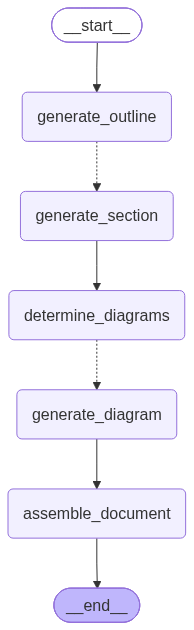

In [36]:
generation_graph

## 8. Standalone End-to-End Generation Validation
Executes `generation_graph.invoke(...)` against a comprehensive `RequirementsModel` fixture:
- Dispatches parallel section workers via `Send()`.
- Dispatches parallel diagram generators & syntax validators via `Send()`.
- Stitches the final Markdown document and writes it to a persistent file.
- Confirms the **Phase 2 Definition of Done**.


In [28]:
# ---------------------------------------------------------------------------
# End-to-End Standalone Generation Subgraph Test
# ---------------------------------------------------------------------------
import time
from pathlib import Path

# 1. Select Test Requirements Fixture
# Uses the output from Phase 1 if available, otherwise uses a rich canned fixture
if 'session_result' in globals() and session_result and "requirements" in session_result:
    test_reqs = session_result["requirements"]
    test_gaps = session_result.get("unresolved_gaps", [])
    print(f"📋 Loaded Requirements from Phase 1: '{test_reqs.project_title}'")
else:
    test_reqs = RequirementsModel(
        project_title="Real-Time Ride-Hailing Platform",
        project_scope="A scalable, real-time ride-hailing and driver dispatch platform connecting mobile riders with nearby vetted drivers.",
        target_users_and_actors=[
            Actor(name="Rider", description="Mobile user requesting rides, viewing real-time driver ETA, and making payments."),
            Actor(name="Driver", description="Vetted mobile driver accepting ride dispatches and navigating routes."),
            Actor(name="Platform Administrator", description="Operations personnel verifying driver documents and monitoring fleet operations."),
            Actor(name="Payment Gateway", description="External PCI-compliant gateway processing card payments and refunds.")
        ],
        functional_requirements=[
            FunctionalRequirement(
                req_id="FR-001",
                title="Rider Authentication & Profile",
                description="Secure mobile registration via phone OTP and passwordless authentication.",
                priority="Must Have",
                acceptance_criteria=["OTP verification in < 15s", "JWT bearer token issuance"]
            ),
            FunctionalRequirement(
                req_id="FR-002",
                title="Real-Time Location Ingestion & Tracking",
                description="Driver location streaming to server at 5-second intervals via WebSockets.",
                priority="Must Have",
                acceptance_criteria=["p99 WebSocket broadcast latency < 200ms", "Map visualization on rider client"]
            ),
            FunctionalRequirement(
                req_id="FR-003",
                title="Ride Matching Engine",
                description="Spatial geospatial query identifying the nearest available driver within 5km radius.",
                priority="Must Have",
                acceptance_criteria=["30s driver acceptance timeout", "Automatic reroute to next closest driver"]
            ),
            FunctionalRequirement(
                req_id="FR-004",
                title="Ride State Machine Enforcement",
                description="Atomic server-side lifecycle transitions: Requested -> Accepted -> Arrived -> In-Progress -> Completed.",
                priority="Must Have",
                acceptance_criteria=["Optimistic locking to prevent race conditions", "Audit log of all transitions"]
            )
        ],
        non_functional_requirements=[
            NonFunctionalRequirement(category="Performance", description="Low-latency location broadcasts", metric="p99 < 200ms at 10k connections"),
            NonFunctionalRequirement(category="Security", description="End-to-end TLS 1.3 encryption and PCI-DSS compliance", metric="100% encrypted traffic"),
            NonFunctionalRequirement(category="Scalability", description="Horizontal scaling under peak commute surges", metric="Support 50,000 active concurrent users")
        ],
        system_constraints=[
            "Backend written in Python FastAPI and Redis",
            "PostgreSQL with PostGIS for geospatial indexing",
            "iOS (v15+) and Android (v10+) mobile clients"
        ],
        assumptions_and_dependencies=[
            "External mapping and routing API availability (e.g. Google Maps / Mapbox)",
            "Stable mobile cellular data connectivity"
        ]
    )
    test_gaps = [
        "Driver payout schedule and fee split policy undefined",
        "Handling of international phone number formats for OTP unspecified"
    ]
    print(f"📋 Loaded Canned Test Fixture: '{test_reqs.project_title}'")

# 2. Prepare Initial GenerationState
initial_generation_state: GenerationState = {
    "requirements": test_reqs,
    "unresolved_gaps": test_gaps,
    "outline": None,
    "section_drafts": [],
    "diagram_specs": [],
    "validated_diagrams": [],
    "final_document": None,
    "diagram_manifest": []
}

print("\n" + "=" * 70)
print("🚀 LAUNCHING STANDALONE GENERATION SUBGRAPH")
print("=" * 70)
start_time = time.time()

# 3. Execute the Subgraph Synchronously
output_state = generation_graph.invoke(initial_generation_state)
elapsed = time.time() - start_time

final_srs_markdown = output_state.get("final_document", "")
manifest = output_state.get("diagram_manifest", [])
outline = output_state.get("outline")

print("\n" + "=" * 70)
print("🎉 GENERATION PIPELINE COMPLETED SUCCESSFULLY!")
print("=" * 70)
print(f"⏱️ Total Execution Time : {elapsed:.2f} seconds")
print(f"📑 Outline Sections     : {len(outline.sections) if outline else 0}")
print(f"📝 Section Drafts Made  : {len(output_state.get('section_drafts', []))}")
print(f"📊 Diagrams Generated   : {len(output_state.get('validated_diagrams', []))}")
print(f"📄 Total SRS Size       : {len(final_srs_markdown):,} characters (~{len(final_srs_markdown.split()):,} words)")

# 4. Save Final Document to File Artifact
output_dir = Path("artifacts")
output_dir.mkdir(exist_ok=True)
doc_file_path = output_dir / "generated_srs_phase2_demo.md"

with open(doc_file_path, "w", encoding="utf-8") as f:
    f.write(final_srs_markdown)

print(f"\n💾 Saved full SRS document to: '{doc_file_path}'")

# 5. Display Diagram Manifest Table
print("\n" + "=" * 70)
print("DIAGRAM MANIFEST SUMMARY:")
print("=" * 70)
for item in manifest:
    print(f"• [{item['diagram_id']}] {item['title']} -> Status: {item['status']} (Section {item['target_section']})")

# 6. Preview Document Header
print("\n" + "=" * 70)
print("DOCUMENT PREVIEW (First 1,500 characters):")
print("=" * 70)
print(final_srs_markdown[:1500] + "\n\n... [remaining document written to file] ...")


📋 Loaded Requirements from Phase 1: 'Islamic Quran Reading Application'

🚀 LAUNCHING STANDALONE GENERATION SUBGRAPH
✓ Outline generated: 'Software Requirements Specification for Islamic Quran Reading Application' (5 major sections)
   [1.0] Introduction
   [2.0] Overall Description
   [3.0] System Features & Functional Requirements
   [4.0] External Interface Requirements
   [5.0] Non-Functional & Quality Attributes
🚀 [Fan-Out] Dispatched 5 parallel section drafting workers.
  ✓ Completed draft for section [1.0] Introduction (3273 chars)
  ✓ Completed draft for section [3.0] System Features & Functional Requirements (3563 chars)
  ✓ Completed draft for section [4.0] External Interface Requirements (3611 chars)
  ✓ Completed draft for section [5.0] Non-Functional & Quality Attributes (3866 chars)
  ✓ Completed draft for section [2.0] Overall Description (3550 chars)

📊 [Diagram Planner] Planned 4 architectural diagrams:
   • [diag-001] System Context Architecture (Type: architecture | T